# Model A + C — OpenLane V1 Data Audit

## 목적

OpenLane V1을 교통사고 과실비율 AI의 Model A + Model C 주 데이터셋으로 사용할 수 있는지 검증한다.

이번 Audit에서는 모델 학습이나 전처리를 바로 시작하지 않는다.

먼저 OpenLane V1의 실제 데이터를 직접 확인하여 다음을 검증한다.

- 이미지와 Lane annotation의 정확한 대응 관계
- 이미지와 CIPO annotation의 정확한 대응 관계
- Scene annotation 구조
- 2D lane (`uv`)의 실제 annotation 품질
- 3D lane (`xyz`)의 실제 annotation 품질
- lane continuity 및 fragmentation 정도
- lane category
- lane visibility
- ego-relative lane attribute
- lane track_id
- CIPO bounding box
- CIPO object type
- CIPO importance level
- CIPO trackid
- 2D / 3D / BEV 시각화 가능 여부
- 사고 분석에 필요한 도로 구조 및 객체 정보를 충분히 제공하는지

최종 목표:

1. 소규모 sanity check
2. 약 10,000개의 matched frame을 이용한 대규모 Data Audit
3. Audit 결과를 바탕으로 Model A + C architecture 확정
4. 이후 OpenLane V1 preprocessing 설계

# 환경 / 경로 / Lane↔CIPO 매칭 기본 구조

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image


# ============================================================
# OpenLane V1 Data Paths
# ============================================================

RAW_ROOT = Path(r"C:\accident_ai\lane_data\open_lane_data\raw")

LANE_ROOT = RAW_ROOT / "lane3d_1000"
CIPO_ROOT = RAW_ROOT / "cipo"
SCENE_JSON_PATH = RAW_ROOT / "scene" / "scene.json"

SPLIT = "training"
SEED = 42

random.seed(SEED)


# ============================================================
# Path Check
# ============================================================

assert RAW_ROOT.exists(), f"RAW_ROOT not found: {RAW_ROOT}"
assert LANE_ROOT.exists(), f"LANE_ROOT not found: {LANE_ROOT}"
assert CIPO_ROOT.exists(), f"CIPO_ROOT not found: {CIPO_ROOT}"
assert SCENE_JSON_PATH.exists(), f"Scene JSON not found: {SCENE_JSON_PATH}"

assert (LANE_ROOT / SPLIT).exists(), (
    f"Lane split not found: {LANE_ROOT / SPLIT}"
)

assert (CIPO_ROOT / SPLIT).exists(), (
    f"CIPO split not found: {CIPO_ROOT / SPLIT}"
)


# ============================================================
# Helper Functions
# ============================================================

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def valid_json_files(root_dir: Path):
    """
    실제 JSON 파일만 가져온다.
    macOS metadata (__MACOSX / ._*)는 제외한다.
    """
    files = []

    for path in root_dir.rglob("*.json"):

        if "__MACOSX" in path.parts:
            continue

        if path.name.startswith("._"):
            continue

        files.append(path)

    return sorted(files)


def list_segment_names(base_dir: Path):
    """
    split 폴더 안의 실제 segment 이름 목록
    """
    return sorted(
        path.name
        for path in base_dir.iterdir()
        if path.is_dir()
        and path.name != "__MACOSX"
        and not path.name.startswith("._")
    )


def get_frame_id(path: Path, source: str):
    """
    OpenLane V1의 서로 다른 파일명 규칙을
    동일한 frame_id로 통일한다.

    Lane
        123456.json
        -> 123456

    CIPO
        123456.jpg.json
        -> 123456
    """

    if source == "lane":
        return path.stem

    if source == "cipo":

        file_name = path.name

        if file_name.endswith(".jpg.json"):
            return file_name[:-len(".jpg.json")]

        # 예상하지 못한 naming이 있을 경우
        return path.stem

    raise ValueError(f"Unknown source: {source}")


def build_frame_map(segment_dir: Path, source: str):
    """
    frame_id -> JSON path
    """
    mapping = {}

    for path in valid_json_files(segment_dir):

        frame_id = get_frame_id(
            path=path,
            source=source,
        )

        if frame_id in mapping:
            raise ValueError(
                f"Duplicate frame_id detected: {frame_id}\n"
                f"Existing: {mapping[frame_id]}\n"
                f"New     : {path}"
            )

        mapping[frame_id] = path

    return mapping


# ============================================================
# Lane ↔ CIPO Segment Matching
# ============================================================

lane_segments = list_segment_names(
    LANE_ROOT / SPLIT
)

cipo_segments = list_segment_names(
    CIPO_ROOT / SPLIT
)

common_segments = sorted(
    set(lane_segments) & set(cipo_segments)
)


print("RAW_ROOT :", RAW_ROOT)
print("LANE_ROOT:", LANE_ROOT)
print("CIPO_ROOT:", CIPO_ROOT)
print("SPLIT    :", SPLIT)

print()

print(f"Lane {SPLIT} segments : {len(lane_segments)}")
print(f"CIPO {SPLIT} segments : {len(cipo_segments)}")
print(f"Common segments       : {len(common_segments)}")


# ============================================================
# Select One Segment
# ============================================================

SEGMENT_INDEX = 0

segment_name = common_segments[SEGMENT_INDEX]

lane_segment_dir = (
    LANE_ROOT
    / SPLIT
    / segment_name
)

cipo_segment_dir = (
    CIPO_ROOT
    / SPLIT
    / segment_name
)


# ============================================================
# Lane ↔ CIPO Frame Matching
# ============================================================

lane_frame_map = build_frame_map(
    lane_segment_dir,
    source="lane",
)

cipo_frame_map = build_frame_map(
    cipo_segment_dir,
    source="cipo",
)

common_frame_ids = sorted(
    set(lane_frame_map) & set(cipo_frame_map)
)


print("\nSelected segment:")
print(segment_name)

print()

print("Lane frame count   :", len(lane_frame_map))
print("CIPO frame count   :", len(cipo_frame_map))
print("Common frame count :", len(common_frame_ids))

print("\nFirst 10 common frame ids:")

for frame_id in common_frame_ids[:10]:
    print(" -", frame_id)


assert len(common_frame_ids) > 0, (
    "Lane과 CIPO의 공통 frame을 찾지 못했습니다."
)

RAW_ROOT : C:\accident_ai\lane_data\open_lane_data\raw
LANE_ROOT: C:\accident_ai\lane_data\open_lane_data\raw\lane3d_1000
CIPO_ROOT: C:\accident_ai\lane_data\open_lane_data\raw\cipo
SPLIT    : training

Lane training segments : 798
CIPO training segments : 798
Common segments       : 798

Selected segment:
segment-10017090168044687777_6380_000_6400_000_with_camera_labels

Lane frame count   : 198
CIPO frame count   : 198
Common frame count : 198

First 10 common frame ids:
 - 155008346734637000
 - 155008346744616300
 - 155008346754599000
 - 155008346764582300
 - 155008346774566500
 - 155008346784553900
 - 155008346794541500
 - 155008346804532700
 - 155008346814523300
 - 155008346824518000


# 동일한 실제 Frame의 Lane JSON + CIPO JSON 열기

In [2]:
# ============================================================
# Cell 3 — Load One Matched Frame
# ============================================================

FRAME_INDEX = 0

frame_id = common_frame_ids[FRAME_INDEX]

lane_json_path = lane_frame_map[frame_id]
cipo_json_path = cipo_frame_map[frame_id]

lane_json = load_json(lane_json_path)
cipo_json = load_json(cipo_json_path)


print("Selected segment :", segment_name)
print("Selected frame   :", frame_id)

print("\n[Lane JSON Path]")
print(lane_json_path)

print("\n[CIPO JSON Path]")
print(cipo_json_path)

print("\n[Lane JSON Top-Level Keys]")
print(list(lane_json.keys()))

print("\n[CIPO JSON Top-Level Keys]")
print(list(cipo_json.keys()))

Selected segment : segment-10017090168044687777_6380_000_6400_000_with_camera_labels
Selected frame   : 155008346734637000

[Lane JSON Path]
C:\accident_ai\lane_data\open_lane_data\raw\lane3d_1000\training\segment-10017090168044687777_6380_000_6400_000_with_camera_labels\155008346734637000.json

[CIPO JSON Path]
C:\accident_ai\lane_data\open_lane_data\raw\cipo\training\segment-10017090168044687777_6380_000_6400_000_with_camera_labels\155008346734637000.jpg.json

[Lane JSON Top-Level Keys]
['extrinsic', 'intrinsic', 'lane_lines', 'file_path', 'pose']

[CIPO JSON Top-Level Keys]
['raw_file_path', 'result']


# 실제 lane_lines 구조 확인

In [3]:
# ============================================================
# Cell 4 — Inspect Actual Lane Annotation Structure
# ============================================================

lane_lines = lane_json["lane_lines"]

print("Lane count :", len(lane_lines))


if len(lane_lines) > 0:

    first_lane = lane_lines[0]

    print("\n[First Lane Keys]")
    print(list(first_lane.keys()))


    print("\n[First Lane Basic Values]")

    for key, value in first_lane.items():

        if key in ["uv", "xyz", "visibility"]:
            array = np.asarray(value)

            print(
                f"{key:12s} : "
                f"type={type(value).__name__}, "
                f"shape={array.shape}"
            )

        else:
            print(
                f"{key:12s} : {value}"
            )


print("\n[Frame-Level Geometry Information]")

print(
    "intrinsic shape :",
    np.asarray(lane_json["intrinsic"]).shape
)

print(
    "extrinsic shape :",
    np.asarray(lane_json["extrinsic"]).shape
)

print(
    "pose shape      :",
    np.asarray(lane_json["pose"]).shape
)

print(
    "file_path       :",
    lane_json["file_path"]
)

Lane count : 2

[First Lane Keys]
['category', 'visibility', 'uv', 'xyz', 'attribute', 'track_id']

[First Lane Basic Values]
category     : 21
visibility   : type=list, shape=(38,)
uv           : type=list, shape=(2, 44)
xyz          : type=list, shape=(3, 38)
attribute    : 0
track_id     : 1

[Frame-Level Geometry Information]
intrinsic shape : (3, 3)
extrinsic shape : (4, 4)
pose shape      : (4, 4)
file_path       : training/segment-10017090168044687777_6380_000_6400_000_with_camera_labels/155008346734637000.jpg


In [4]:
# ============================================================
# Cell 5 — Inspect Actual CIPO Annotation Structure
# ============================================================

cipo_results = cipo_json["result"]

print("CIPO object count :", len(cipo_results))


if len(cipo_results) > 0:

    first_cipo = cipo_results[0]

    print("\n[First CIPO Object Keys]")
    print(list(first_cipo.keys()))

    print("\n[First CIPO Object Values]")

    for key, value in first_cipo.items():
        print(f"{key:15s} : {value}")

else:
    print("No CIPO objects in this frame.")


print("\n[CIPO Frame Information]")

print(
    "raw_file_path :",
    cipo_json.get("raw_file_path")
)

CIPO object count : 5

[First CIPO Object Keys]
['width', 'height', 'x', 'y', 'trackid', 'id', 'type']

[First CIPO Object Values]
width           : 240.63579000000004
height          : 109.89666
x               : 1346.234085
y               : 437.69187
trackid         : 12ba81ee-9cee-4134-94ca-df9ed01e0ff1
id              : 4
type            : 1

[CIPO Frame Information]
raw_file_path : training/segment-10017090168044687777_6380_000_6400_000_with_camera_labels/155008346734637000.jpg


In [5]:
# ============================================================
# Cell 6 — Inspect Actual Scene Metadata Structure
# ============================================================

scene_json = load_json(SCENE_JSON_PATH)

print("[Scene JSON Basic Information]")
print("type        :", type(scene_json).__name__)
print("entry count :", len(scene_json))


# ------------------------------------------------------------
# Top-level preview
# ------------------------------------------------------------

if isinstance(scene_json, dict):

    scene_keys = list(scene_json.keys())

    print("\n[First 5 Scene Keys]")

    for key in scene_keys[:5]:
        print(" -", key)

    print("\n[First Scene Entry]")

    first_scene_key = scene_keys[0]

    print("key   :", first_scene_key)
    print("value :", scene_json[first_scene_key])


else:

    print("\n[First Scene Entries]")

    for item in scene_json[:5]:
        print(item)


# ------------------------------------------------------------
# Try exact match with currently selected segment
# ------------------------------------------------------------

print("\n[Current Segment Matching]")

if isinstance(scene_json, dict) and segment_name in scene_json:

    print("Exact segment match : YES")
    print(scene_json[segment_name])

else:

    print("Exact segment match : NO")
    print("Scene key naming rule needs inspection.")

[Scene JSON Basic Information]
type        : dict
entry count : 1000

[First 5 Scene Keys]
 - segment-18141076662151909970_2755_710_2775_710_with_camera_labels
 - segment-17778522338768131809_5920_000_5940_000_with_camera_labels
 - segment-17759280403078053118_6060_580_6080_580_with_camera_labels
 - segment-17674974223808194792_8787_692_8807_692_with_camera_labels
 - segment-17601040886987343289_472_000_492_000_with_camera_labels

[First Scene Entry]
key   : segment-18141076662151909970_2755_710_2775_710_with_camera_labels
value : {'scene': 'Residential area houses', 'weather': 'Clear', 'hours': 'Daytime'}

[Current Segment Matching]
Exact segment match : YES
{'scene': 'Residential area houses', 'weather': 'Rainy', 'hours': 'Daytime'}


In [6]:
# ============================================================
# Cell 7 — RGB ↔ Lane ↔ CIPO 3-Way Matching
# ============================================================

IMAGE_ROOT = RAW_ROOT / "images_training_0"

assert IMAGE_ROOT.exists(), f"IMAGE_ROOT not found: {IMAGE_ROOT}"


# ------------------------------------------------------------
# Image segment list
# ------------------------------------------------------------

image_segments = sorted(
    path.name
    for path in IMAGE_ROOT.iterdir()
    if path.is_dir()
    and path.name != "__MACOSX"
    and not path.name.startswith("._")
)


# Lane + CIPO + RGB가 모두 존재하는 segment
common_3way_segments = sorted(
    set(image_segments)
    & set(common_segments)
)


print("Image segments              :", len(image_segments))
print("Lane + CIPO common segments :", len(common_segments))
print("RGB + Lane + CIPO segments  :", len(common_3way_segments))

print("\nFirst 5 RGB + Lane + CIPO segments:")

for name in common_3way_segments[:5]:
    print(" -", name)


assert len(common_3way_segments) > 0, (
    "RGB / Lane / CIPO가 모두 존재하는 segment가 없습니다."
)


# ------------------------------------------------------------
# Select one matched segment
# ------------------------------------------------------------

AUDIT_SEGMENT_INDEX = 0

audit_segment_name = common_3way_segments[AUDIT_SEGMENT_INDEX]

image_segment_dir = (
    IMAGE_ROOT
    / audit_segment_name
)

lane_audit_segment_dir = (
    LANE_ROOT
    / SPLIT
    / audit_segment_name
)

cipo_audit_segment_dir = (
    CIPO_ROOT
    / SPLIT
    / audit_segment_name
)


# ------------------------------------------------------------
# Build frame maps
# ------------------------------------------------------------

image_frame_map = {
    path.stem: path
    for path in sorted(image_segment_dir.glob("*.jpg"))
    if not path.name.startswith("._")
}

lane_audit_frame_map = build_frame_map(
    lane_audit_segment_dir,
    source="lane",
)

cipo_audit_frame_map = build_frame_map(
    cipo_audit_segment_dir,
    source="cipo",
)


# ------------------------------------------------------------
# RGB + Lane + CIPO common frames
# ------------------------------------------------------------

common_3way_frame_ids = sorted(
    set(image_frame_map)
    & set(lane_audit_frame_map)
    & set(cipo_audit_frame_map)
)


print("\nSelected audit segment:")
print(audit_segment_name)

print("\nFrame counts")
print("RGB frames              :", len(image_frame_map))
print("Lane frames             :", len(lane_audit_frame_map))
print("CIPO frames             :", len(cipo_audit_frame_map))
print("RGB + Lane + CIPO frames:", len(common_3way_frame_ids))


print("\nFirst 10 matched frame ids:")

for fid in common_3way_frame_ids[:10]:
    print(" -", fid)


assert len(common_3way_frame_ids) > 0, (
    "선택한 segment에서 RGB / Lane / CIPO 공통 frame을 찾지 못했습니다."
)


# ------------------------------------------------------------
# Select one fully matched frame
# ------------------------------------------------------------

AUDIT_FRAME_INDEX = 0

audit_frame_id = common_3way_frame_ids[AUDIT_FRAME_INDEX]

audit_image_path = image_frame_map[audit_frame_id]
audit_lane_json_path = lane_audit_frame_map[audit_frame_id]
audit_cipo_json_path = cipo_audit_frame_map[audit_frame_id]


print("\n[Selected Fully Matched Frame]")

print("frame_id :", audit_frame_id)

print("\nRGB")
print(audit_image_path)

print("\nLane")
print(audit_lane_json_path)

print("\nCIPO")
print(audit_cipo_json_path)

Image segments              : 50
Lane + CIPO common segments : 798
RGB + Lane + CIPO segments  : 50

First 5 RGB + Lane + CIPO segments:
 - segment-10094743350625019937_3420_000_3440_000_with_camera_labels
 - segment-10153695247769592104_787_000_807_000_with_camera_labels
 - segment-10206293520369375008_2796_800_2816_800_with_camera_labels
 - segment-10391312872392849784_4099_400_4119_400_with_camera_labels
 - segment-1051897962568538022_238_170_258_170_with_camera_labels

Selected audit segment:
segment-10094743350625019937_3420_000_3440_000_with_camera_labels

Frame counts
RGB frames              : 199
Lane frames             : 199
CIPO frames             : 199
RGB + Lane + CIPO frames: 199

First 10 matched frame ids:
 - 155362930427409000
 - 155362930437411700
 - 155362930447414100
 - 155362930457412700
 - 155362930467411700
 - 155362930477413500
 - 155362930487411100
 - 155362930497413300
 - 155362930507408700
 - 155362930517407400

[Selected Fully Matched Frame]
frame_id : 155362

[Selected RGB Frame]
segment : segment-10094743350625019937_3420_000_3440_000_with_camera_labels
frame   : 155362930427409000

image path:
C:\accident_ai\lane_data\open_lane_data\raw\images_training_0\segment-10094743350625019937_3420_000_3440_000_with_camera_labels\155362930427409000.jpg

image size (W, H):
(1920, 1280)


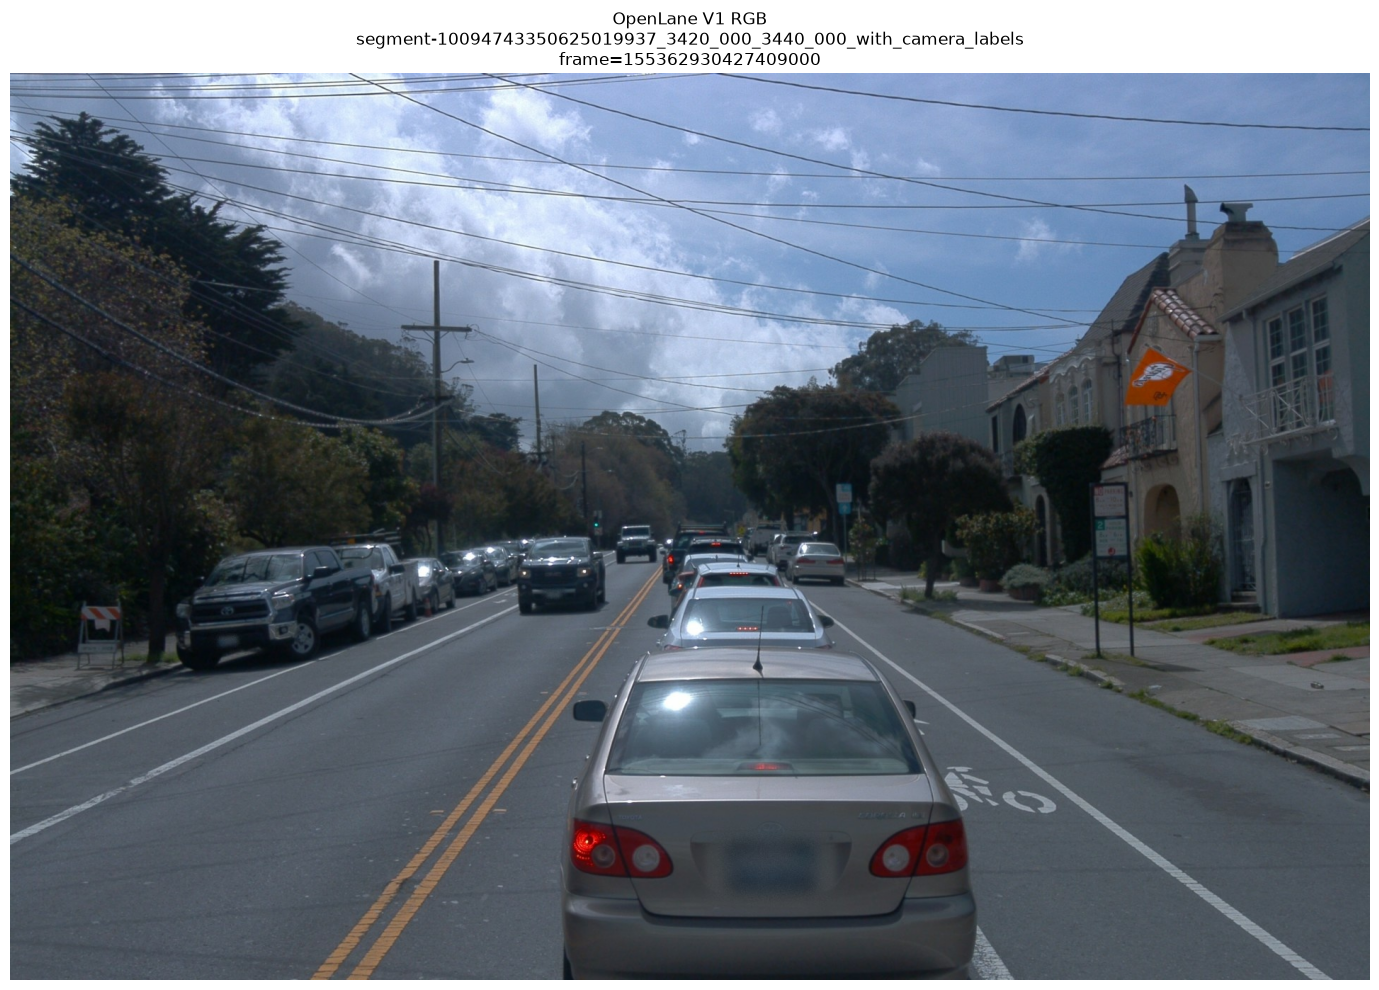

In [7]:
# ============================================================
# Cell 8 — Visualize One Fully Matched RGB Frame
# ============================================================

audit_image = Image.open(
    audit_image_path
).convert("RGB")


print("[Selected RGB Frame]")

print("segment :", audit_segment_name)
print("frame   :", audit_frame_id)

print("\nimage path:")
print(audit_image_path)

print("\nimage size (W, H):")
print(audit_image.size)


plt.figure(figsize=(16, 10))

plt.imshow(audit_image)

plt.title(
    f"OpenLane V1 RGB\n"
    f"{audit_segment_name}\n"
    f"frame={audit_frame_id}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

[Lane ↔ RGB Matching Check]
RGB frame_id       : 155362930427409000
Lane file_path     : training/segment-10094743350625019937_3420_000_3440_000_with_camera_labels/155362930427409000.jpg
Lane count         : 6
Image size (W, H)  : (1920, 1280)


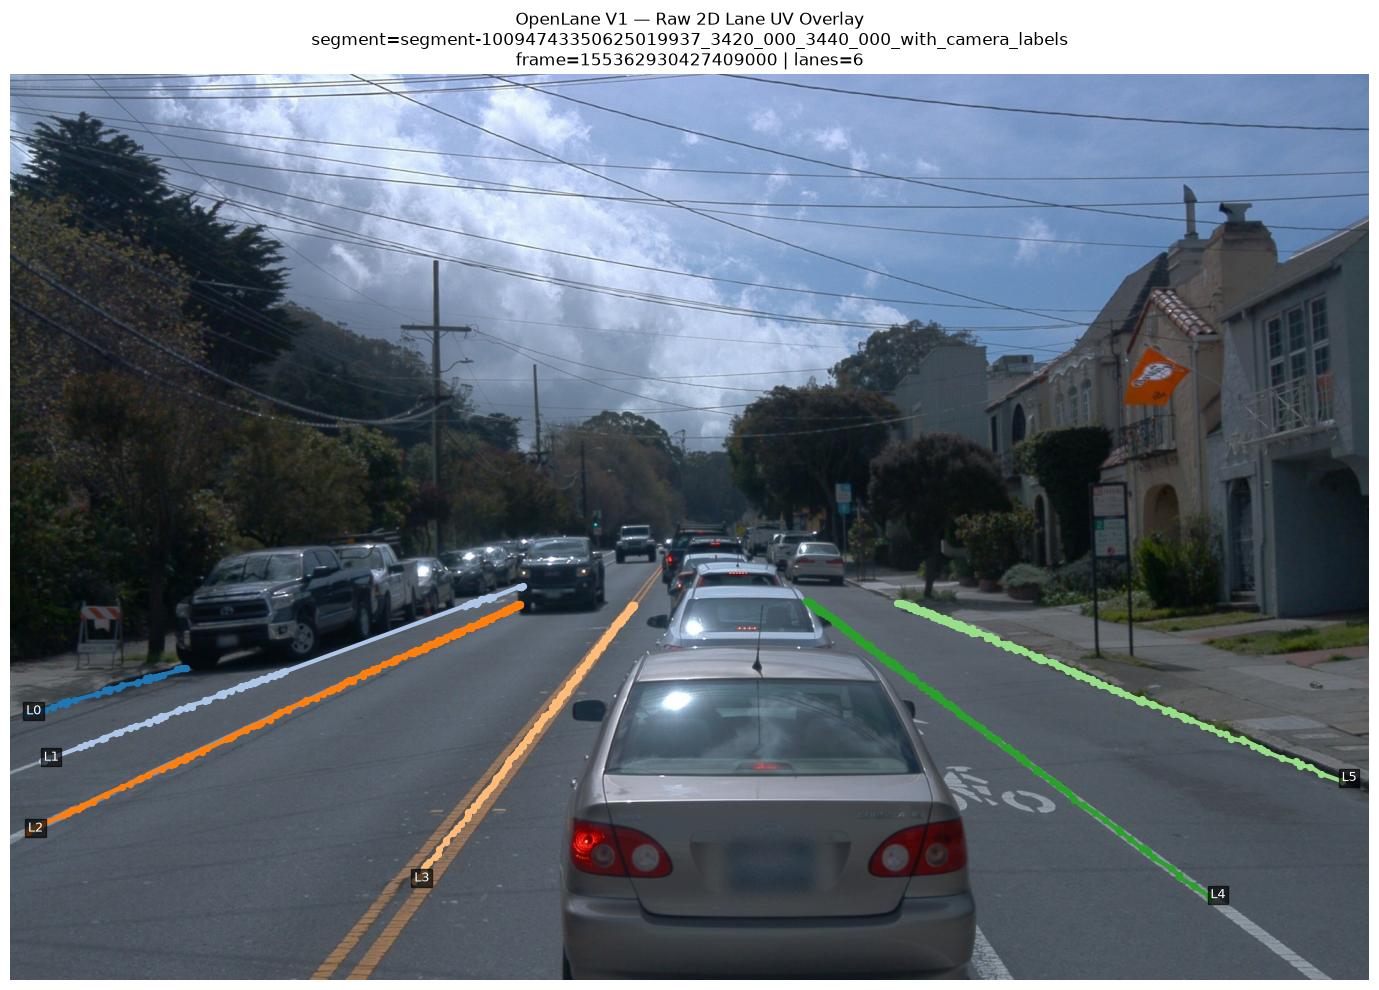

In [8]:
# ============================================================
# Cell 9 — Visualize All 2D Lane UV Annotations
# ============================================================

# 현재 RGB와 정확히 매칭된 Lane JSON
audit_lane_json = load_json(audit_lane_json_path)

audit_lane_lines = audit_lane_json["lane_lines"]

image_width, image_height = audit_image.size


# ------------------------------------------------------------
# Basic matching check
# ------------------------------------------------------------

print("[Lane ↔ RGB Matching Check]")

print("RGB frame_id       :", audit_frame_id)
print("Lane file_path     :", audit_lane_json.get("file_path"))
print("Lane count         :", len(audit_lane_lines))
print("Image size (W, H)  :", audit_image.size)


# ------------------------------------------------------------
# Visualize raw UV
# ------------------------------------------------------------

plt.figure(figsize=(16, 10))

plt.imshow(audit_image)

cmap = plt.get_cmap("tab20")


for lane_index, lane in enumerate(audit_lane_lines):

    uv = np.asarray(
        lane["uv"],
        dtype=float
    )

    # OpenLane V1 실제 구조:
    # uv shape = (2, N)
    if uv.ndim != 2 or uv.shape[0] != 2:
        print(
            f"[WARNING] Lane {lane_index}: "
            f"unexpected uv shape {uv.shape}"
        )
        continue

    u = uv[0]
    v = uv[1]

    # NaN / inf 방어
    valid = (
        np.isfinite(u)
        & np.isfinite(v)
    )

    u = u[valid]
    v = v[valid]

    if len(u) < 2:
        continue

    color = cmap(
        lane_index % cmap.N
    )

    # Lane polyline
    plt.plot(
        u,
        v,
        linewidth=3,
        color=color,
    )

    # 실제 annotation points
    plt.scatter(
        u,
        v,
        s=18,
        color=[color],
    )

    # Lane index만 표시
    plt.text(
        u[0],
        v[0],
        f"L{lane_index}",
        fontsize=9,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.65,
            pad=2,
        ),
    )


plt.xlim(0, image_width)
plt.ylim(image_height, 0)

plt.title(
    "OpenLane V1 — Raw 2D Lane UV Overlay\n"
    f"segment={audit_segment_name}\n"
    f"frame={audit_frame_id} | lanes={len(audit_lane_lines)}"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Cell 10 — Lane Internal Continuity Audit
# ============================================================

import pandas as pd


def to_nx2(uv):
    arr = np.asarray(uv, dtype=float)

    if arr.ndim != 2:
        return np.empty((0, 2), dtype=float)

    if arr.shape[0] == 2:
        arr = arr.T

    elif arr.shape[1] == 2:
        pass

    else:
        return np.empty((0, 2), dtype=float)

    valid = np.isfinite(arr).all(axis=1)

    return arr[valid]


def to_nx3(xyz):
    arr = np.asarray(xyz, dtype=float)

    if arr.ndim != 2:
        return np.empty((0, 3), dtype=float)

    if arr.shape[0] == 3:
        arr = arr.T

    elif arr.shape[1] == 3:
        pass

    else:
        return np.empty((0, 3), dtype=float)

    valid = np.isfinite(arr).all(axis=1)

    return arr[valid]


def continuity_stats(points, base_gap_threshold):
    """
    한 lane instance 안에서
    consecutive annotation point 간 거리를 조사한다.

    주의:
    이것은 fragment 확정 판정이 아니라
    비정상적으로 큰 point gap을 찾는 1차 audit 지표이다.
    """

    n = len(points)

    if n == 0:
        return {
            "point_count": 0,
            "median_gap": np.nan,
            "max_gap": np.nan,
            "gap_threshold": np.nan,
            "break_count": 0,
            "break_indices": [],
        }

    if n == 1:
        return {
            "point_count": 1,
            "median_gap": 0.0,
            "max_gap": 0.0,
            "gap_threshold": base_gap_threshold,
            "break_count": 0,
            "break_indices": [],
        }

    gaps = np.linalg.norm(
        points[1:] - points[:-1],
        axis=1,
    )

    median_gap = float(np.median(gaps))
    max_gap = float(np.max(gaps))

    gap_threshold = max(
        base_gap_threshold,
        median_gap * 3.0,
    )

    break_indices = np.where(
        gaps > gap_threshold
    )[0].tolist()

    return {
        "point_count": n,
        "median_gap": median_gap,
        "max_gap": max_gap,
        "gap_threshold": gap_threshold,
        "break_count": len(break_indices),
        "break_indices": break_indices,
    }


lane_rows = []


# 중요:
# 현재 RGB와 정확히 matching된 audit_lane_lines 사용
for lane_idx, lane in enumerate(audit_lane_lines):

    uv = to_nx2(
        lane.get("uv", [])
    )

    xyz = to_nx3(
        lane.get("xyz", [])
    )

    uv_stats = continuity_stats(
        uv,
        base_gap_threshold=80.0,
    )

    xyz_stats = continuity_stats(
        xyz,
        base_gap_threshold=3.0,
    )

    lane_rows.append({
        "lane_idx": lane_idx,

        "category": lane.get("category"),
        "attribute": lane.get("attribute"),
        "track_id": lane.get("track_id"),

        "uv_points": uv_stats["point_count"],
        "uv_median_gap": uv_stats["median_gap"],
        "uv_max_gap": uv_stats["max_gap"],
        "uv_gap_threshold": uv_stats["gap_threshold"],
        "uv_break_count": uv_stats["break_count"],

        "xyz_points": xyz_stats["point_count"],
        "xyz_median_gap": xyz_stats["median_gap"],
        "xyz_max_gap": xyz_stats["max_gap"],
        "xyz_gap_threshold": xyz_stats["gap_threshold"],
        "xyz_break_count": xyz_stats["break_count"],
    })


lane_summary_df = pd.DataFrame(
    lane_rows
)


print("segment :", audit_segment_name)
print("frame   :", audit_frame_id)
print("lanes   :", len(audit_lane_lines))

lane_summary_df

segment : segment-10094743350625019937_3420_000_3440_000_with_camera_labels
frame   : 155362930427409000
lanes   : 6


,lane_idx,category,attribute,track_id,uv_points,uv_median_gap,uv_max_gap,uv_gap_threshold,uv_break_count,xyz_points,xyz_median_gap,xyz_max_gap,xyz_gap_threshold,xyz_break_count
0,0,20,0,1,32,6.415108,33.893903,80.0,0,35,0.154017,1.901518,3.0,0
1,1,2,0,2,83,5.315158,269.976097,80.0,1,151,0.142192,18.763930,3.0,3
2,2,2,1,3,171,5.468607,60.934330,80.0,0,275,0.158686,1.333338,3.0,0
3,3,10,2,4,257,5.218055,25.546977,80.0,0,539,0.123740,2.646838,3.0,0
4,4,2,3,6,232,2.646454,38.291753,80.0,0,485,0.132307,19.163271,3.0,2
5,5,21,0,7,159,8.939824,40.071402,80.0,0,242,0.138989,0.613689,3.0,0


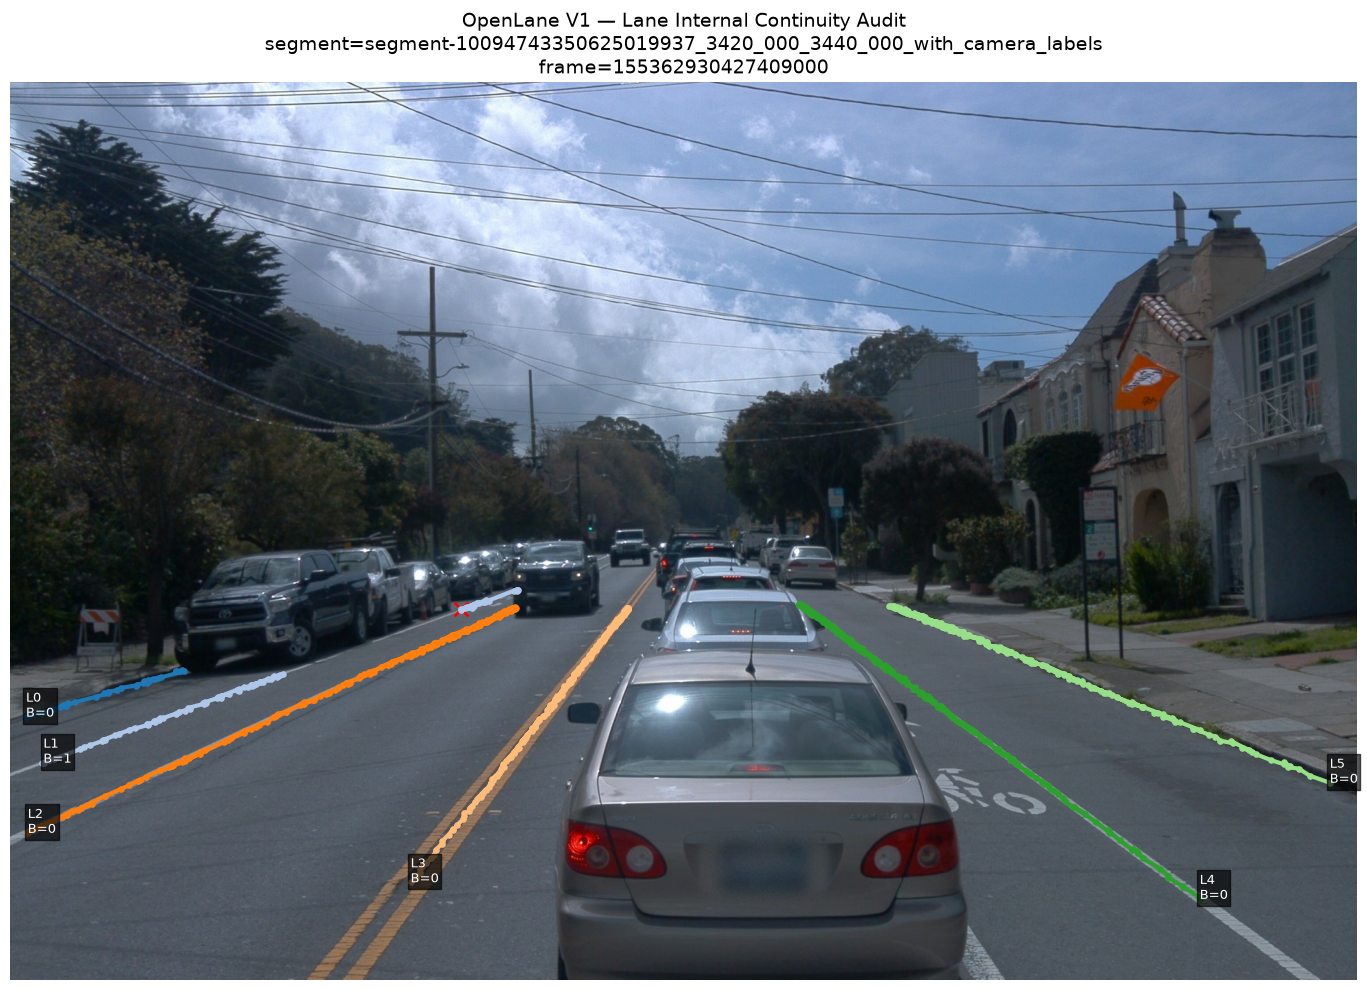

In [12]:
# ============================================================
# Cell 11 — Visualize Possible Internal Lane Breaks
# ============================================================

img = np.asarray(
    audit_image
)


fig, ax = plt.subplots(
    figsize=(16, 10)
)

ax.imshow(img)


ax.set_title(
    "OpenLane V1 — Lane Internal Continuity Audit\n"
    f"segment={audit_segment_name}\n"
    f"frame={audit_frame_id}",
    fontsize=14,
)


cmap = plt.get_cmap(
    "tab20"
)


for lane_idx, lane in enumerate(audit_lane_lines):

    uv = to_nx2(
        lane.get("uv", [])
    )

    if len(uv) < 2:
        continue


    stats = continuity_stats(
        uv,
        base_gap_threshold=80.0,
    )

    color = cmap(
        lane_idx % cmap.N
    )

    break_indices = stats["break_indices"]


    # --------------------------------------------
    # Break가 없는 경우
    # --------------------------------------------

    if len(break_indices) == 0:

        ax.plot(
            uv[:, 0],
            uv[:, 1],
            linewidth=3,
            color=color,
        )


    # --------------------------------------------
    # 큰 gap이 있는 경우
    # --------------------------------------------

    else:

        start = 0

        for break_idx in break_indices:

            segment_uv = uv[
                start:break_idx + 1
            ]

            if len(segment_uv) >= 2:
                ax.plot(
                    segment_uv[:, 0],
                    segment_uv[:, 1],
                    linewidth=3,
                    color=color,
                )

            start = break_idx + 1


        segment_uv = uv[start:]

        if len(segment_uv) >= 2:
            ax.plot(
                segment_uv[:, 0],
                segment_uv[:, 1],
                linewidth=3,
                color=color,
            )


        # 큰 gap이 발생한 다음 point 표시
        break_points = uv[
            np.asarray(break_indices) + 1
        ]

        ax.scatter(
            break_points[:, 0],
            break_points[:, 1],
            s=100,
            marker="x",
            color="red",
            linewidths=2,
        )


    # annotation points
    ax.scatter(
        uv[:, 0],
        uv[:, 1],
        s=14,
        color=[color],
    )


    # lane label
    anchor = uv[0]

    ax.text(
        anchor[0],
        anchor[1],
        (
            f"L{lane_idx}\n"
            f"B={stats['break_count']}"
        ),
        fontsize=9,
        color="white",
        bbox=dict(
            facecolor="black",
            alpha=0.65,
            pad=2,
        ),
    )


ax.set_xlim(
    0,
    img.shape[1],
)

ax.set_ylim(
    img.shape[0],
    0,
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 12 — Possible Fragment Candidates
# ============================================================

fragment_candidate_df = lane_summary_df[
    (lane_summary_df["uv_break_count"] > 0)
    |
    (lane_summary_df["xyz_break_count"] > 0)
].copy()


print(
    "Possible fragment candidate lanes :",
    len(fragment_candidate_df),
    "/",
    len(lane_summary_df),
)


fragment_candidate_df

Possible fragment candidate lanes : 2 / 6


,lane_idx,category,attribute,track_id,uv_points,uv_median_gap,uv_max_gap,uv_gap_threshold,uv_break_count,xyz_points,xyz_median_gap,xyz_max_gap,xyz_gap_threshold,xyz_break_count
1,1,2,0,2,83,5.315158,269.976097,80.0,1,151,0.142192,18.763930,3.0,3
4,4,2,3,6,232,2.646454,38.291753,80.0,0,485,0.132307,19.163271,3.0,2
